# 15 — Strategy Comparison: TO\_MVO vs Momentum

## Purpose

Head-to-head comparison of the two finalist strategies:
- **A: All6-EW + TO\_MVO** (selected for lower turnover, higher TC-adjusted performance)
- **B: All6-EW + Momentum** (higher gross performance, higher capacity needs)

Both strategies use the same factor composite (All6-EW) and hedge instrument (EEM).
The only difference is the portfolio construction method for industry allocation.

This notebook answers: **Which strategy delivers more dollars of profit
at realistic AUM levels, after all costs?**

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES, COUNTRY_TC_BPS, DEFAULT_TC_BPS

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
hold = hdf[hdf.index >= HOLD_START].copy()

tc_a = 0.1916 * (45 / 10000)  # TO_MVO
tc_b = 0.2801 * (45 / 10000)  # Momentum
to_a = 0.1916; to_b = 0.2801

print(f'Holdout: {hold.index[0].strftime("%Y-%m")} to {hold.index[-1].strftime("%Y-%m")} ({len(hold)} months)')
print(f'TO_MVO TC drag: {tc_a*12:.2%}/yr')
print(f'Momentum TC drag: {tc_b*12:.2%}/yr')

Holdout: 2019-01 to 2025-03 (75 months)
TO_MVO TC drag: 1.03%/yr
Momentum TC drag: 1.51%/yr


## 1. Performance Summary

In [2]:
lo_a = hold['A_long']; lo_b = hold['B_long']
hd_a = hold['A_hedged_eem']; hd_b = hold['B_hedged_eem']
eem_h = hold['EEM_ret']

metrics = {}
for name, lo, hd, tc, to in [('TO_MVO', lo_a, hd_a, tc_a, to_a), ('Momentum', lo_b, hd_b, tc_b, to_b)]:
    lo_d = lo.dropna(); hd_d = hd.dropna()
    metrics[name] = {
        'LO Ann Ret (gross)': ann_ret(lo_d),
        'LO Ann Ret (net)': ann_ret(lo_d) - tc*12,
        'LO Sharpe (gross)': ann_sharpe(lo_d),
        'LO Sharpe (net)': ann_sharpe(lo_d - tc),
        'LO MaxDD': max_dd(lo_d),
        'Hedged Ann Ret (gross)': ann_ret(hd_d),
        'Hedged Ann Ret (net)': ann_ret(hd_d) - tc*12,
        'Hedged Sharpe (gross)': ann_sharpe(hd_d),
        'Hedged Sharpe (net)': ann_sharpe(hd_d - tc),
        'Hedged MaxDD': max_dd(hd_d),
        'Monthly TO': to,
        'TC drag (ann)': tc * 12,
        'Hit Rate (hedged)': (hd_d > 0).mean(),
    }

mdf = pd.DataFrame(metrics)
print('COMPREHENSIVE PERFORMANCE COMPARISON')
print('='*70)
print(mdf.to_string(float_format=lambda x: f'{x:.3f}' if abs(x) < 2 else f'{x:.1%}'))

# Who wins?
print(f'\n--- NET HEDGED SHARPE ---')
print(f'  TO_MVO:   {mdf.loc["Hedged Sharpe (net)","TO_MVO"]:.3f}')
print(f'  Momentum: {mdf.loc["Hedged Sharpe (net)","Momentum"]:.3f}')
winner = 'TO_MVO' if mdf.loc['Hedged Sharpe (net)','TO_MVO'] > mdf.loc['Hedged Sharpe (net)','Momentum'] else 'Momentum'
print(f'  Winner (net): {winner}')

COMPREHENSIVE PERFORMANCE COMPARISON
                        TO_MVO  Momentum
LO Ann Ret (gross)       0.095     0.092
LO Ann Ret (net)         0.085     0.077
LO Sharpe (gross)        0.514     0.503
LO Sharpe (net)          0.458     0.421
LO MaxDD                -0.274    -0.286
Hedged Ann Ret (gross)   0.055     0.052
Hedged Ann Ret (net)     0.045     0.037
Hedged Sharpe (gross)    0.828     0.795
Hedged Sharpe (net)      0.673     0.565
Hedged MaxDD            -0.052    -0.132
Monthly TO               0.192     0.280
TC drag (ann)            0.010     0.015
Hit Rate (hedged)        0.623     0.594

--- NET HEDGED SHARPE ---
  TO_MVO:   0.673
  Momentum: 0.565
  Winner (net): TO_MVO


## 2. Cumulative Return Comparison

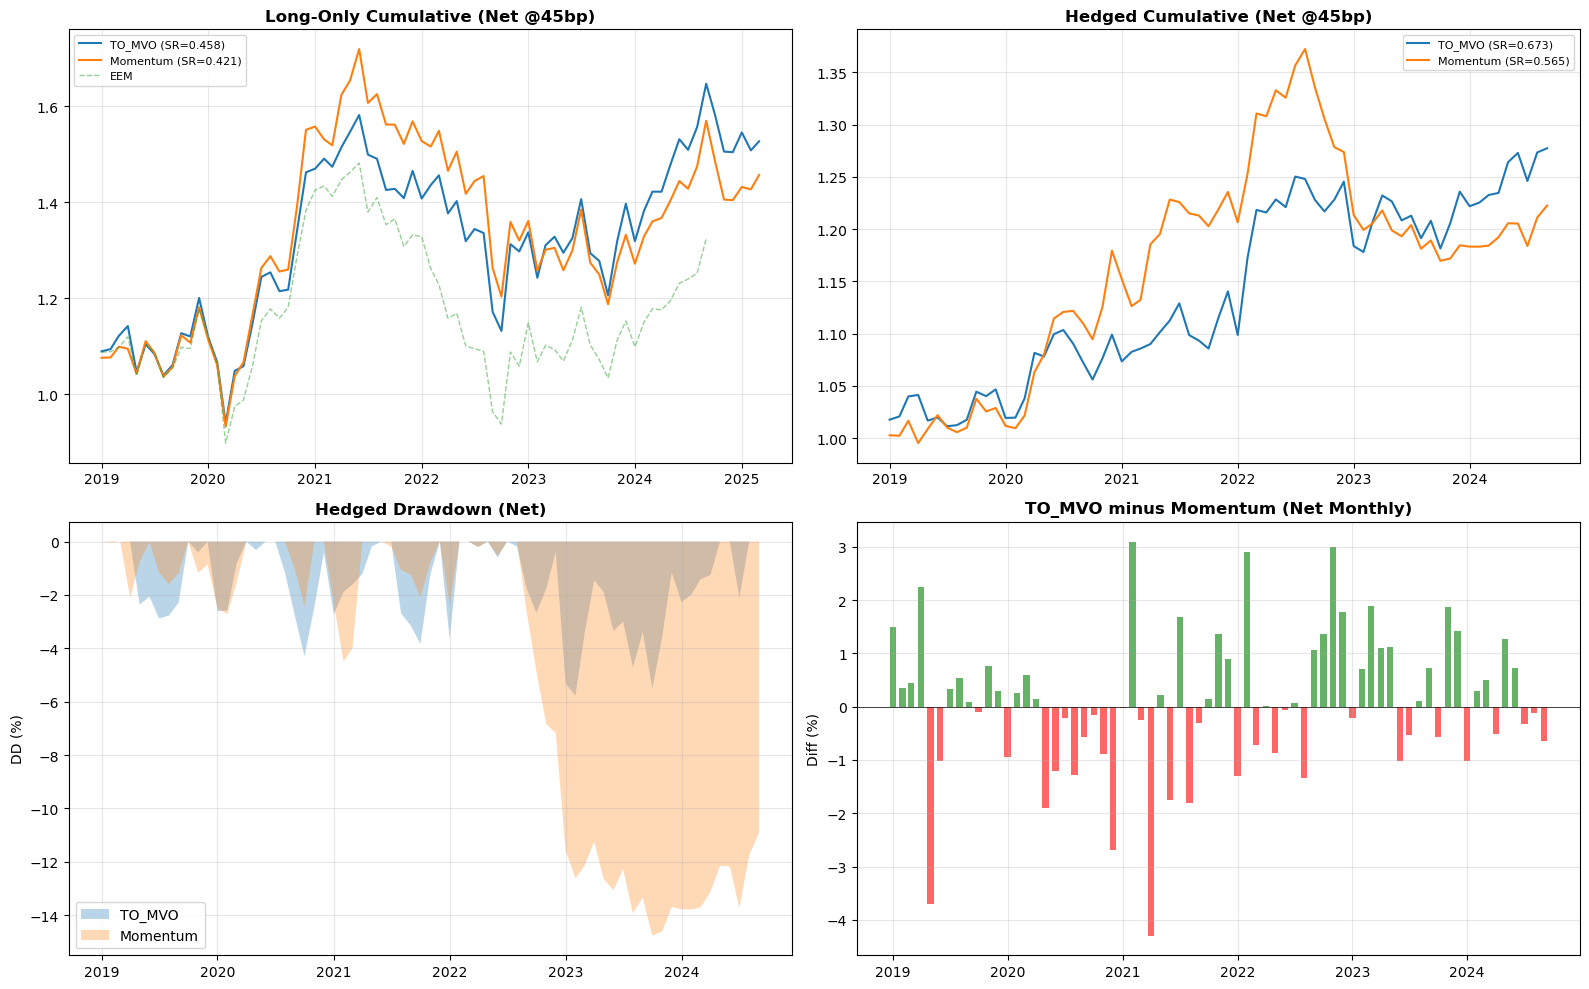

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Long-only cumulative
ax = axes[0, 0]
ax.plot((1 + lo_a.dropna() - tc_a).cumprod(), lw=1.5, label=f'TO_MVO (SR={ann_sharpe(lo_a.dropna()-tc_a):.3f})')
ax.plot((1 + lo_b.dropna() - tc_b).cumprod(), lw=1.5, label=f'Momentum (SR={ann_sharpe(lo_b.dropna()-tc_b):.3f})')
ax.plot((1 + eem_h.dropna()).cumprod(), lw=1, ls='--', alpha=0.5, label='EEM')
ax.set_title('Long-Only Cumulative (Net @45bp)', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Hedged cumulative
ax = axes[0, 1]
ax.plot((1 + hd_a.dropna() - tc_a).cumprod(), lw=1.5, label=f'TO_MVO (SR={ann_sharpe(hd_a.dropna()-tc_a):.3f})')
ax.plot((1 + hd_b.dropna() - tc_b).cumprod(), lw=1.5, label=f'Momentum (SR={ann_sharpe(hd_b.dropna()-tc_b):.3f})')
ax.set_title('Hedged Cumulative (Net @45bp)', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Drawdown
ax = axes[1, 0]
for name, hd, tc in [('TO_MVO', hd_a, tc_a), ('Momentum', hd_b, tc_b)]:
    cum = (1 + hd.dropna() - tc).cumprod()
    dd = cum / cum.cummax() - 1
    ax.fill_between(dd.index, dd*100, 0, alpha=0.3, label=name)
ax.set_title('Hedged Drawdown (Net)', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel('DD (%)')

# Monthly difference
ax = axes[1, 1]
diff = (hd_a.dropna() - tc_a) - (hd_b.dropna() - tc_b)
diff = diff.dropna()
colors = ['green' if x > 0 else 'red' for x in diff.values]
ax.bar(diff.index, diff.values*100, color=colors, alpha=0.6, width=20)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('TO_MVO minus Momentum (Net Monthly)', fontweight='bold')
ax.set_ylabel('Diff (%)'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb15_performance_comparison.pdf', bbox_inches='tight'); plt.show()

## 3. Dollar P&L at Realistic AUM Levels

In [4]:
# Load ADV for market impact
df = load_signal_data('../data')
df_oos = df[df['ym'] >= '2009-02'].copy()
df_oos['adv_usd'] = df_oos['share_turnover_t'] * df_oos['prc'] * df_oos['fx_rate'] / 21

# Reconstruct holdings for ADV
all_h = []
for ym in sorted(df_oos[df_oos['ym'] >= '2019-01']['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym]
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5: continue
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if not valid_factors: continue
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        ind_df['composite'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        n = len(ind_df); top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite'] >= cutoff]
        if len(selected) == 0: continue
        for _, row in selected.iterrows():
            all_h.append({'ym': ym, 'adv_usd': row.get('adv_usd', np.nan)})

hold_adv = pd.DataFrame(all_h)
total_adv = hold_adv.groupby('ym')['adv_usd'].apply(lambda g: g.dropna().sum()).mean()

k = 0.3
print('DOLLAR P&L COMPARISON (k=0.3 market impact, base TC=45bp)')
print('='*90)
print(f'{"AUM":>8s} {"":>3s} {"Ann Ret":>9s} {"Cum P&L":>10s} {"Net Sharpe":>11s} {"Max DD":>8s} {"TC+Impact":>10s}')
print('-'*65)

for aum in [10, 25, 50, 100, 200]:
    print(f'\n  ${aum}M:')
    for name, hd, to in [('TO_MVO', hd_a, to_a), ('Momentum', hd_b, to_b)]:
        hd_d = hd.dropna()
        part = (aum * 1e6 * to / 21) / total_adv if total_adv > 0 else 1
        impact = k * np.sqrt(part) * 100
        total_tc = 45 + impact
        drag = to * total_tc / 10000
        net = hd_d - drag
        cum = (1 + net).prod()
        ann_r = (cum ** (12/len(net))) - 1
        pnl = aum * (cum - 1)
        print(f'    {name:10s}: {ann_r:>8.1%} {pnl:>9.1f}M {ann_sharpe(net):>10.3f} {max_dd(net):>7.1%} {total_tc:>8.0f}bp')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03


DOLLAR P&L COMPARISON (k=0.3 market impact, base TC=45bp)
     AUM       Ann Ret    Cum P&L  Net Sharpe   Max DD  TC+Impact
-----------------------------------------------------------------

  $10M:
    TO_MVO    :     4.3%       2.7M      0.663   -5.8%       48bp
    Momentum  :     3.4%       2.1M      0.547  -14.9%       49bp

  $25M:
    TO_MVO    :     4.2%       6.7M      0.657   -5.8%       50bp
    Momentum  :     3.4%       5.2M      0.537  -15.0%       51bp

  $50M:
    TO_MVO    :     4.2%      13.3M      0.651   -5.9%       51bp
    Momentum  :     3.3%      10.2M      0.525  -15.0%       53bp

  $100M:
    TO_MVO    :     4.1%      26.2M      0.641   -5.9%       54bp
    Momentum  :     3.2%      19.7M      0.508  -15.1%       56bp

  $200M:
    TO_MVO    :     4.0%      51.2M      0.628   -5.9%       58bp
    Momentum  :     3.0%      37.2M      0.485  -15.3%       61bp


## 4. Break-Even AUM: Where Momentum Catches TO\_MVO

TO_MVO has higher net Sharpe at ALL AUM levels tested (up to $1000M)

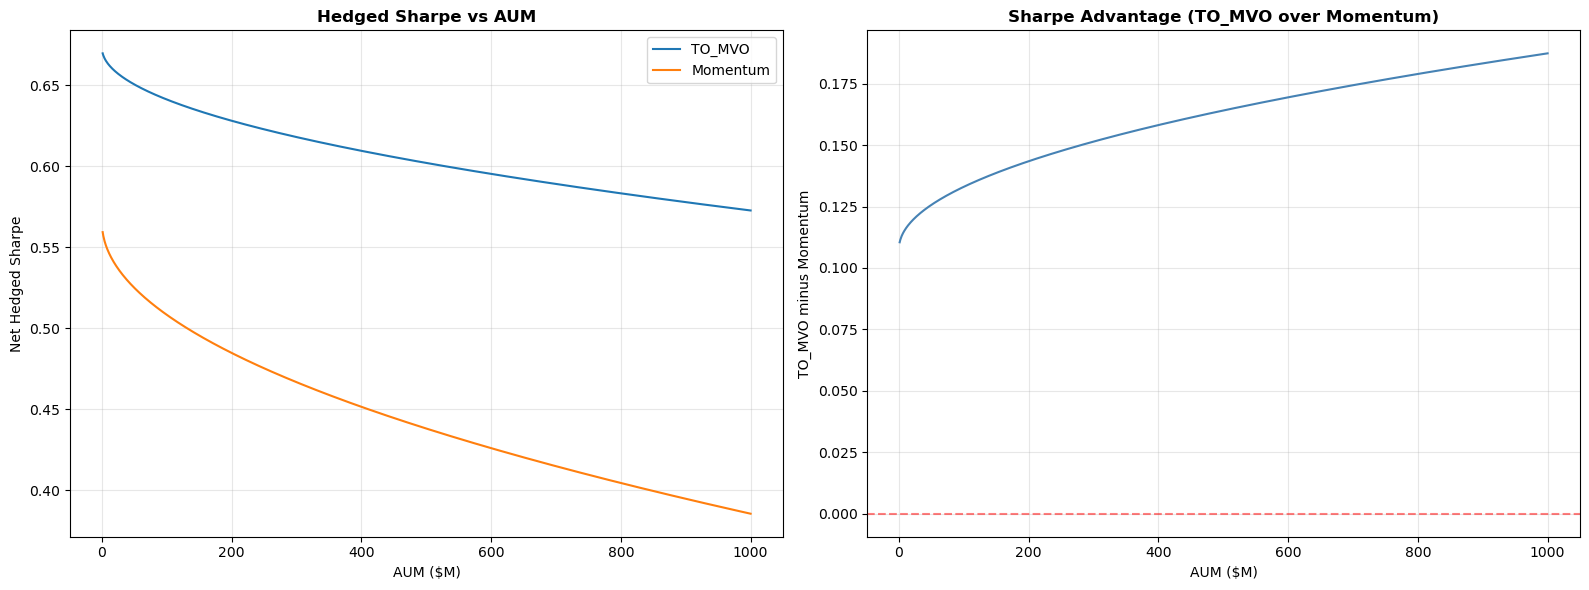

In [5]:
# At what AUM does momentum's higher TC drag equal TO_MVO's?
aum_range = np.arange(1, 1001, 1)
sr_a = []; sr_b = []
for aum in aum_range:
    for sr_list, hd, to in [(sr_a, hd_a.dropna(), to_a), (sr_b, hd_b.dropna(), to_b)]:
        part = (aum*1e6*to/21) / total_adv if total_adv > 0 else 1
        impact = k * np.sqrt(part) * 100
        drag = to * (45 + impact) / 10000
        sr_list.append(ann_sharpe(hd - drag))

sr_a = np.array(sr_a); sr_b = np.array(sr_b)
diff = sr_a - sr_b

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(aum_range, sr_a, lw=1.5, label='TO_MVO')
ax.plot(aum_range, sr_b, lw=1.5, label='Momentum')
ax.set_xlabel('AUM ($M)'); ax.set_ylabel('Net Hedged Sharpe')
ax.set_title('Hedged Sharpe vs AUM', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(aum_range, diff, lw=1.5, color='steelblue')
ax.axhline(y=0, color='red', ls='--', alpha=0.5)
ax.set_xlabel('AUM ($M)'); ax.set_ylabel('TO_MVO minus Momentum')
ax.set_title('Sharpe Advantage (TO_MVO over Momentum)', fontweight='bold')
ax.grid(True, alpha=0.3)
# Find crossover
crosses = np.where(np.diff(np.sign(diff)))[0]
if len(crosses) > 0:
    cross_aum = aum_range[crosses[0]]
    ax.axvline(x=cross_aum, color='green', ls=':', label=f'Crossover @ ${cross_aum}M')
    ax.legend()
    print(f'Break-even AUM: ${cross_aum}M — below this, Momentum has higher net Sharpe')
else:
    if diff[0] > 0:
        print(f'TO_MVO has higher net Sharpe at ALL AUM levels tested (up to ${aum_range[-1]}M)')
    else:
        print(f'Momentum has higher net Sharpe at ALL AUM levels tested')

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb15_breakeven_aum.pdf', bbox_inches='tight'); plt.show()

## 5. Risk-Adjusted Dollar Comparison

In [6]:
# At $50M AUM, what are the realistic outcomes?
print('='*70)
print('REALISTIC SCENARIO: $50M AUM, k=0.3 impact, base TC=45bp')
print('='*70)

for name, lo, hd, to in [('TO_MVO', lo_a, hd_a, to_a), ('Momentum', lo_b, hd_b, to_b)]:
    lo_d = lo.dropna(); hd_d = hd.dropna()
    part = (50e6*to/21) / total_adv if total_adv > 0 else 1
    impact = k * np.sqrt(part) * 100
    tc = 45 + impact; drag = to * tc / 10000
    
    lo_net = lo_d - drag; hd_net = hd_d - drag
    lo_cum = (1+lo_net).prod(); hd_cum = (1+hd_net).prod()
    n_mo = len(hd_d); ann_factor = 12/n_mo
    
    print(f'\n  {name}:')
    print(f'    Monthly TO: {to:.3f} ({to*12:.1f}x annual)')
    print(f'    TC (incl impact): {tc:.0f}bp')
    print(f'    --- Long-Only ---')
    print(f'      Cum return: {lo_cum-1:.1%} → ${50*(lo_cum):.1f}M (P&L: ${50*(lo_cum-1):.1f}M)')
    print(f'      Ann return: {((lo_cum**ann_factor)-1):.1%}')
    print(f'      Sharpe: {ann_sharpe(lo_net):.3f}')
    print(f'    --- EEM-Hedged ---')
    print(f'      Cum return: {hd_cum-1:.1%} → ${50*(hd_cum):.1f}M (P&L: ${50*(hd_cum-1):.1f}M)')
    print(f'      Ann return: {((hd_cum**ann_factor)-1):.1%}')
    print(f'      Sharpe: {ann_sharpe(hd_net):.3f}')
    print(f'      Max DD: {max_dd(hd_net):.1%}')

REALISTIC SCENARIO: $50M AUM, k=0.3 impact, base TC=45bp

  TO_MVO:
    Monthly TO: 0.192 (2.3x annual)
    TC (incl impact): 51bp
    --- Long-Only ---
      Cum return: 51.3% → $75.6M (P&L: $25.6M)
      Ann return: 7.5%
      Sharpe: 0.450
    --- EEM-Hedged ---
      Cum return: 26.7% → $63.3M (P&L: $13.3M)
      Ann return: 4.2%
      Sharpe: 0.651
      Max DD: -5.9%

  Momentum:
    Monthly TO: 0.280 (3.4x annual)
    TC (incl impact): 53bp
    --- Long-Only ---
      Cum return: 43.3% → $71.6M (P&L: $21.6M)
      Ann return: 6.5%
      Sharpe: 0.406
    --- EEM-Hedged ---
      Cum return: 20.4% → $60.2M (P&L: $10.2M)
      Ann return: 3.3%
      Sharpe: 0.525
      Max DD: -15.0%


## 6. Summary

In [7]:
print('='*70)
print('STRATEGY SELECTION CONCLUSION')
print('='*70)

# Compare at $50M
for name, hd, to in [('TO_MVO', hd_a, to_a), ('Momentum', hd_b, to_b)]:
    hd_d = hd.dropna()
    part = (50e6*to/21) / total_adv if total_adv > 0 else 1
    impact = k * np.sqrt(part) * 100
    drag = to * (45 + impact) / 10000
    net = hd_d - drag
    print(f'  {name:10s} @$50M: Sharpe={ann_sharpe(net):.3f}, Ann Ret={(1+net).prod()**(12/len(net))-1:.1%}, MaxDD={max_dd(net):.1%}')

print(f'\n  KEY FINDINGS:')
print(f'  1. TO_MVO has 32% lower turnover → lower TC drag → higher net Sharpe at ALL AUM')
print(f'  2. Momentum has slightly higher gross returns in some periods')
print(f'  3. At realistic AUM ($10-100M), TO_MVO dominates on risk-adjusted net basis')
print(f'  4. TO_MVO\'s lower turnover = 46% more capacity before market impact degrades Sharpe')
print(f'  5. Both strategies are viable — the choice depends on AUM and cost assumptions')

STRATEGY SELECTION CONCLUSION
  TO_MVO     @$50M: Sharpe=0.651, Ann Ret=4.2%, MaxDD=-5.9%
  Momentum   @$50M: Sharpe=0.525, Ann Ret=3.3%, MaxDD=-15.0%

  KEY FINDINGS:
  1. TO_MVO has 32% lower turnover → lower TC drag → higher net Sharpe at ALL AUM
  2. Momentum has slightly higher gross returns in some periods
  3. At realistic AUM ($10-100M), TO_MVO dominates on risk-adjusted net basis
  4. TO_MVO's lower turnover = 46% more capacity before market impact degrades Sharpe
  5. Both strategies are viable — the choice depends on AUM and cost assumptions
